In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import importlib

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import encoder_classifier as ec
importlib.reload(ec)

<module 'encoder_classifier' from 'c:\\Users\\Utente\\Desktop\\uni\\MAGISTRALE\\___TESI_magistrale\\github\\prove_modelli\\encoder_classifier.py'>

# 0. DATA LOADING

In [5]:
# -------------       
# DATASET PATHS
# -------------
train_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv"
test_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv"

# -------------------------
# TRAINING DATA PREPARATION
# -------------------------
train_dataset, train_loader, waves_train, labels_train = ec.dataload_csv(train_path)


# ---------------------
# TEST DATA PREPARATION
# ---------------------
test_dataset, test_loader, waves_test, labels_test = ec.dataload_csv(test_path)


# ---------------------------
# TEST PLOT TO VISUALISE DATA
# ---------------------------
# ec.plot_wave(waves_train)
# ec.plot_wave(waves_test)

This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv...


Data loaded successfully. Waves shape: torch.Size([3601, 1, 500]), Labels shape: torch.Size([3601])
This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv...
Data loaded successfully. Waves shape: torch.Size([1320, 1, 500]), Labels shape: torch.Size([1320])


# 1. AUTOENCODER training + test

Epoch [1/500] - Average loss: 0.3644
Epoch [2/500] - Average loss: 0.1248
Epoch [3/500] - Average loss: 0.0902
Epoch [4/500] - Average loss: 0.0771
Epoch [5/500] - Average loss: 0.0572
Epoch [6/500] - Average loss: 0.0489
Epoch [7/500] - Average loss: 0.0403
Epoch [8/500] - Average loss: 0.0350
Epoch [9/500] - Average loss: 0.0300
Epoch [10/500] - Average loss: 0.0300
Epoch [11/500] - Average loss: 0.0288
Epoch [12/500] - Average loss: 0.0255
Epoch [13/500] - Average loss: 0.0243
Epoch [14/500] - Average loss: 0.0240
Epoch [15/500] - Average loss: 0.0215
Epoch [16/500] - Average loss: 0.0198
Epoch [17/500] - Average loss: 0.0194
Epoch [18/500] - Average loss: 0.0172
Epoch [19/500] - Average loss: 0.0180
Epoch [20/500] - Average loss: 0.0163
Epoch [21/500] - Average loss: 0.0144
Epoch [22/500] - Average loss: 0.0145
Epoch [23/500] - Average loss: 0.0167
Epoch [24/500] - Average loss: 0.0158
Epoch [25/500] - Average loss: 0.0154
Epoch [26/500] - Average loss: 0.0147
Epoch [27/500] - Aver

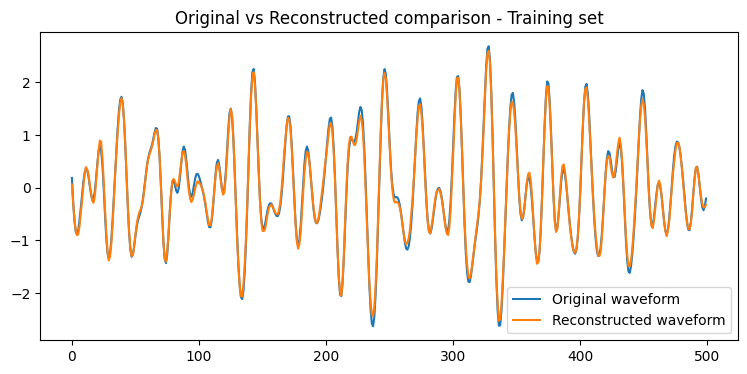

In [6]:
# ------------------------------------
# MODEL TRAINING for the FordA dataset
# ------------------------------------

FordA_model = ec.AutoEncoder()

# This comand put the model in training mode 
# that means that some mathematichal structures are behaving in a specific mode
FordA_model.train() 

trained_ae_FordA = ec.train_autoencoder(FordA_model, train_loader, epochs=500)

Recontruction - Test result: Average loss: 0.0083


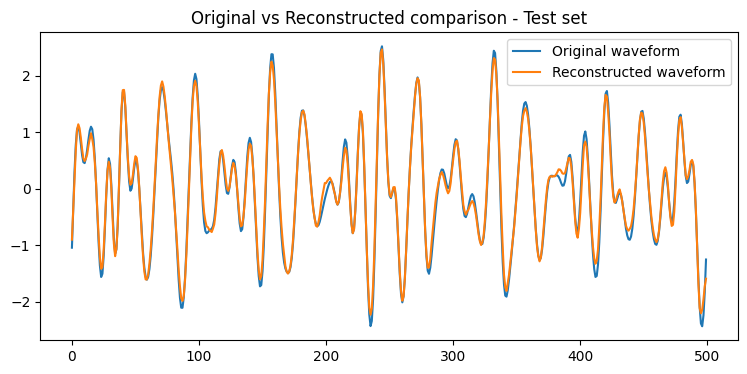

In [7]:
# -----------------------
# TEST of the FordA_model
# -----------------------

tested_ae_FordA = ec.test_autoencoder(trained_ae_FordA, test_loader)


# 2. CLASSIFIER

In [10]:
# -----------------------
# TRAIN of the CLASSIFIER
# -----------------------

FordA_classifier = ec.Classifier()

classifier_FordA = ec.train_classifier(trained_ae_FordA, FordA_classifier, train_loader, epochs=500)

Dataset splittato: 2880 sample per il Train, 721 sample per la Validation.

Epoch [1/500] 
Train Loss: 0.6452 
Validation Loss: 0.5495 
Train Accuracy: 58.89%
Epoch [2/500] 
Train Loss: 0.5437 
Validation Loss: 0.5127 
Train Accuracy: 72.43%
Epoch [3/500] 
Train Loss: 0.4718 
Validation Loss: 0.4292 
Train Accuracy: 78.44%
Epoch [4/500] 
Train Loss: 0.4287 
Validation Loss: 0.3909 
Train Accuracy: 80.83%
Epoch [5/500] 
Train Loss: 0.3919 
Validation Loss: 0.4051 
Train Accuracy: 82.81%
Epoch [6/500] 
Train Loss: 0.3699 
Validation Loss: 0.3433 
Train Accuracy: 83.51%
Epoch [7/500] 
Train Loss: 0.3620 
Validation Loss: 0.3724 
Train Accuracy: 83.99%
Epoch [8/500] 
Train Loss: 0.3578 
Validation Loss: 0.3175 
Train Accuracy: 85.24%
Epoch [9/500] 
Train Loss: 0.3139 
Validation Loss: 0.3417 
Train Accuracy: 86.91%
Epoch [10/500] 
Train Loss: 0.3091 
Validation Loss: 0.2983 
Train Accuracy: 86.18%
Epoch [11/500] 
Train Loss: 0.3035 
Validation Loss: 0.2907 
Train Accuracy: 87.26%
Epoch [12

In [11]:
# ----------------------
# TEST of the CLASSIFIER
# ----------------------

tested_classifier_FordA = ec.test_classifier(trained_ae_FordA, classifier_FordA, test_loader)


Classification - Test result: 
Average loss: 0.2351 
Accuracy: 90.45%
